In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import TensorBoard
import datetime

In [2]:
def build_model(input_shape=(32,32,3), num_classes=10):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

In [3]:
def plot_history(history):
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='train loss')
    plt.plot(history.history['val_loss'], label='val loss')
    plt.legend(); plt.title('Loss')
    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'], label='train acc')
    plt.plot(history.history['val_accuracy'], label='val acc')
    plt.legend(); plt.title('Accuracy')
    plt.show()

In [4]:
def visualize_first_layer(model, x_sample):
    _ = model(tf.zeros((1, 32, 32, 3)))

    first_conv = None
    for layer in model.layers:
        if isinstance(layer, layers.Conv2D):
            first_conv = layer
            break
    assert first_conv is not None, "No Conv2D layer found"

    activation_model = models.Model(
        inputs=model.inputs,
        outputs=first_conv.output
    )

    activations = activation_model.predict(
        np.expand_dims(x_sample, 0),
        verbose=0
    )[0]

    n_maps = activations.shape[-1]
    cols = 8
    rows = int(np.ceil(n_maps / cols))

    plt.figure(figsize=(cols * 1.5, rows * 1.5))
    for i in range(n_maps):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(activations[:, :, i], cmap="viridis")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [5]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [6]:
model = build_model()
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 16, 16, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 8, 8, 64)         0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 8, 8, 128)         73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 4, 4, 128)        0

In [7]:
log_dir = "logs/cifar_keras/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(
    log_dir=log_dir,
    histogram_freq=1,      # log weight histograms
    write_graph=True,
    write_images=False
)

In [8]:
EPOCHS = 10
BATCH_SIZE = 64

history = model.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=2,
    callbacks=[tensorboard_callback]
)

Epoch 1/10
704/704 - 52s - loss: 1.5133 - accuracy: 0.4506 - val_loss: 1.2354 - val_accuracy: 0.5656 - 52s/epoch - 73ms/step
Epoch 2/10
704/704 - 70s - loss: 1.0854 - accuracy: 0.6183 - val_loss: 1.0223 - val_accuracy: 0.6436 - 70s/epoch - 99ms/step
Epoch 3/10
704/704 - 65s - loss: 0.9084 - accuracy: 0.6798 - val_loss: 0.8461 - val_accuracy: 0.7098 - 65s/epoch - 93ms/step
Epoch 4/10
704/704 - 67s - loss: 0.7934 - accuracy: 0.7265 - val_loss: 0.8867 - val_accuracy: 0.6980 - 67s/epoch - 95ms/step
Epoch 5/10
704/704 - 65s - loss: 0.7164 - accuracy: 0.7508 - val_loss: 0.7713 - val_accuracy: 0.7392 - 65s/epoch - 92ms/step
Epoch 6/10
704/704 - 65s - loss: 0.6361 - accuracy: 0.7778 - val_loss: 0.7800 - val_accuracy: 0.7380 - 65s/epoch - 92ms/step
Epoch 7/10
704/704 - 68s - loss: 0.5720 - accuracy: 0.7995 - val_loss: 0.7544 - val_accuracy: 0.7474 - 68s/epoch - 97ms/step
Epoch 8/10
704/704 - 63s - loss: 0.5092 - accuracy: 0.8203 - val_loss: 0.7969 - val_accuracy: 0.7390 - 63s/epoch - 90ms/step


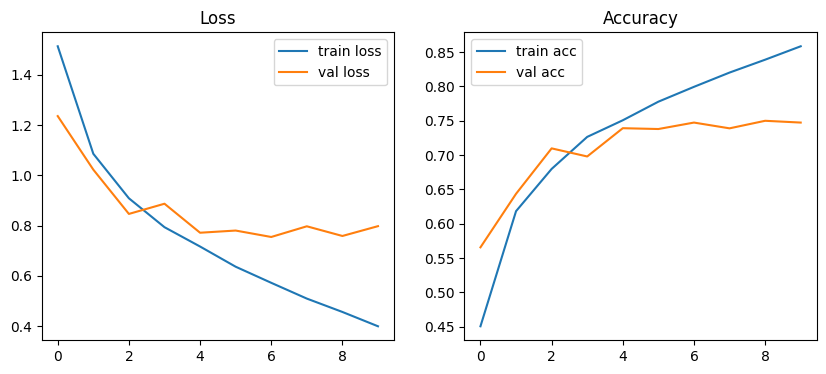

In [9]:
plot_history(history)

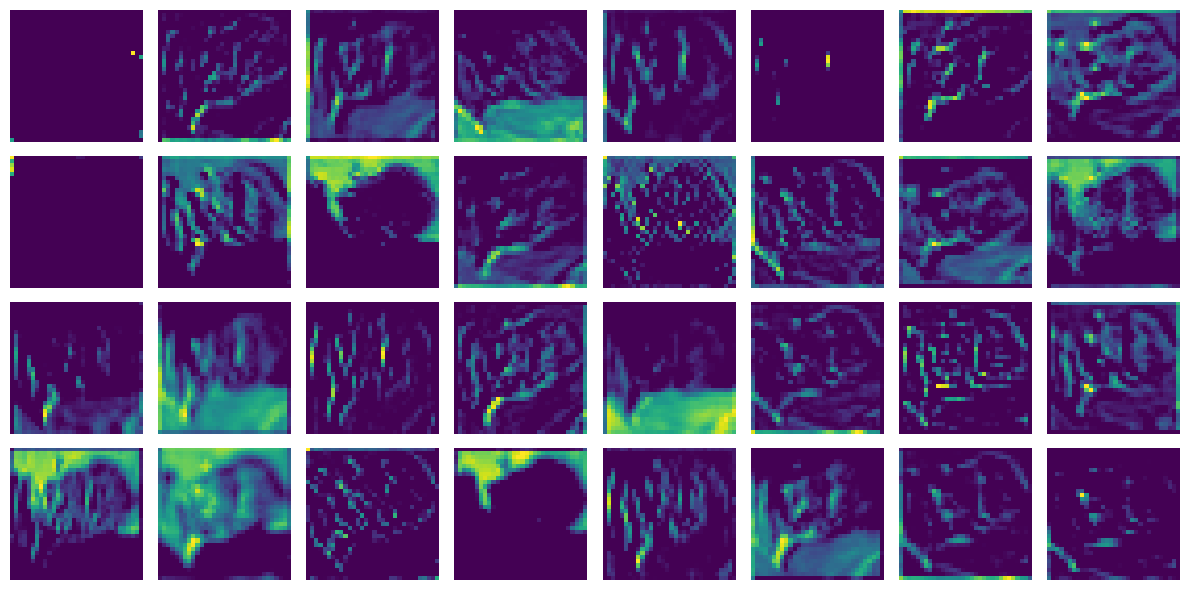

In [10]:
visualize_first_layer(model, x_test[0])